In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.stats_dataset import analyser_variables_binaires
from utils.feature_transformer import transform_features, _convert_all_columns_to_numeric
from utils.data_quality import nettoyer_nan_par_colonne
from utils.data_quality import analyser_nan,nettoyer_lignes_vides,nettoyer_colonnes
from utils.feature_loader import load_feature_lists, load_diagnostic_feature_map
import sys
# loads the col
FEATURE_CONFIG_PATH = "../utils/feature_columns.json"
feature_lists = load_feature_lists(FEATURE_CONFIG_PATH)
Liste_features_simple = feature_lists["Liste_features_simple"]
features_radiology_dysfunction = feature_lists["features_radiology_dysfunction"]
features_etiology = feature_lists["features_etiology"]
features_death = feature_lists["death"]
# Charger le fichier Excel
df = pd.read_excel(r"C:\Users\romai\Desktop\travail\EFRAIM3 JD VANCE.xlsx")

# Malade que d'hemato 
# df["Hem_mal"] = pd.to_numeric(df["Hem_mal"], errors="coerce").fillna(0)
# df = df[df["Hem_mal"] != 0]
# separer colonnes explicatives et etiology
df = df[df['Etiology_Undetermined cause_Definitive diagnosis'] != 1]
features_etiology.remove('Etiology_Undetermined cause_Definitive diagnosis')

diagnostic_feature_map = load_diagnostic_feature_map(
    FEATURE_CONFIG_PATH,
    available_columns=df.columns,
    diagnoses = ["Bacterial infection","default"]
)
all_feature_columns = []
for columns_list in diagnostic_feature_map.values():
    for feature_name in columns_list:
        if feature_name not in all_feature_columns:
            all_feature_columns.append(feature_name)
Liste_features = all_feature_columns
df_col_utils = df[Liste_features]
df_category = df[features_etiology]
df_death = df[features_death]
DIAGNOSTIC_FEATURES = diagnostic_feature_map
L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score","Neutrophils","Temp","Sp02","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features
}
strategie_fill_nan["DG1"] = "str"
strategie_fill_nan["DG2"] = "str"
strategie_fill_nan["Sys_dis_spec"] = "str"
df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)
# resultats = analyser_nan(df_col_utils, top_n=3)
# resultats_y = analyser_nan(df_category, top_n=8)
df_category = nettoyer_colonnes(df_category)
df_cat_clean,index_a_drop = nettoyer_lignes_vides(df_category)
df_features_clean = df_features_clean.drop(index=index_a_drop)
df_features_clean = _convert_all_columns_to_numeric(df_features_clean)

🔹 Age → NaN remplacés par la médiane (64.0)
🔹 Time H-ICU → NaN remplacés par la médiane (2.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (2.0)
🔹 SOFA_score → NaN remplacés par la médiane (7.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 Temp → NaN remplacés par la médiane (37.3)
🔹 PaO2/FiO2 VALUE VALUE → NaN remplacés par la médiane (88.0)
🔹 Neutrophils → NaN remplacés par la médiane (7.17)
🔹 Leukocytes → NaN remplacés par la médiane (9.51)
🔹 Quad_no → NaN remplacés par la médiane (3.0)
⚠️ Colonne 'Sys_dis_spec' absente du DataFrame, ignorée.

✅ Nettoyage terminé. NaN restants : 0
Nombre de lignes totalement vides : 3055


In [3]:
df_cardio = df_cat_clean[(df_cat_clean["Cardiogenic pulmonary oedema"] == 1) & (df_cat_clean["Pneumocystis jirovecii infection"] == 1)]
len(df_cardio)/len(df_cat_clean)
#print([x for x in df_cardio if x in df_pneumo])

0.002830188679245283

In [17]:
df_features_clean

,Sex,Time H-ICU,TIME SYMPTOMES-ICU,Time DG-ICU,Sys_dis,Solid_tumor,Organ_transpl,Drug_induced,Chemotherapy,Ibr_Flu_Met,...,Resp_severity,Temp_gravité,Leukostase,Neutropenie,Hypotension,Alveolar,Indication_prophy_anti_fun,Indication_prophy_pneumocystose,Pneumonia_microbio,Pneumonia_clinic
2,1.0,0.947368,0.947368,0.989011,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.500000,0.888889,0.999917,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.000000,0.997403,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.6,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0
5,0.0,0.666667,0.750000,0.997653,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.6,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
6,1.0,0.800000,0.500000,0.991935,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9846,0.0,0.666667,0.000000,0.999375,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.6,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
9848,1.0,0.833333,0.833333,0.999643,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
9851,1.0,0.979167,0.900000,0.997722,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0
9852,1.0,0.909091,0.000000,0.952381,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [19]:
df__with_diag = pd.concat([df_features_clean,df_cat_clean],axis=1)
df__with_diag

,Sex,Time H-ICU,TIME SYMPTOMES-ICU,Time DG-ICU,Sys_dis,Solid_tumor,Organ_transpl,Drug_induced,Chemotherapy,Ibr_Flu_Met,...,Invasive pulmonary aspergillosis,Pneumocystis jirovecii infection,Mucorales,Other fungal,Other infection,Cardiogenic pulmonary oedema,Drug toxicity related,Disease-related infiltrates,Transfusion-related acute lung injury,Other non infectious causes
2,1.0,0.947368,0.947368,0.989011,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.500000,0.888889,0.999917,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.000000,0.000000,0.997403,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.666667,0.750000,0.997653,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,1.0,0.800000,0.500000,0.991935,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9846,0.0,0.666667,0.000000,0.999375,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9848,1.0,0.833333,0.833333,0.999643,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9851,1.0,0.979167,0.900000,0.997722,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9852,1.0,0.909091,0.000000,0.952381,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [25]:
df__with_diag[["Pneumonia_microbio","Pneumonia_clinic","Bacterial infection"]].value_counts(dropna=False)

Pneumonia_microbio  Pneumonia_clinic  Bacterial infection
0.0                 0.0               0.0                    2842
1.0                 0.0               1.0                    1901
0.0                 0.0               1.0                     724
1.0                 0.0               0.0                     656
0.0                 1.0               0.0                      91
Name: count, dtype: int64

In [26]:
df__with_diag = pd.concat([df_features_clean,df_cat_clean],axis=1)

enlever_clinic = lambda X: ((X["Pneumonia_clinic"] == 1) & (X["Pneumonia_microbio"] == 0) & (X["Bacterial infection"] == 1))
mask = enlever_clinic(df__with_diag)
df_features_clean = df_features_clean[~mask]
df_cat_clean = df_cat_clean[~mask]

df_features_clean

,Sex,Time H-ICU,TIME SYMPTOMES-ICU,Time DG-ICU,Sys_dis,Solid_tumor,Organ_transpl,Drug_induced,Chemotherapy,Ibr_Flu_Met,...,Resp_severity,Temp_gravité,Leukostase,Neutropenie,Hypotension,Alveolar,Indication_prophy_anti_fun,Indication_prophy_pneumocystose,Pneumonia_microbio,Pneumonia_clinic
2,1.0,0.947368,0.947368,0.989011,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.500000,0.888889,0.999917,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.000000,0.997403,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.6,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0
5,0.0,0.666667,0.750000,0.997653,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.6,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
6,1.0,0.800000,0.500000,0.991935,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9846,0.0,0.666667,0.000000,0.999375,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.6,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
9848,1.0,0.833333,0.833333,0.999643,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
9851,1.0,0.979167,0.900000,0.997722,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0
9852,1.0,0.909091,0.000000,0.952381,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [4]:
for x in df_cat_clean.columns:
    print(x )

Bacterial infection
Viral infection
Invasive pulmonary aspergillosis
Pneumocystis jirovecii infection
Mucorales
Other fungal 
Other infection 
Cardiogenic pulmonary oedema
Drug toxicity related
Disease-related infiltrates
Transfusion-related acute lung injury
Other non infectious causes


In [6]:
df_category[df_category.isna().all(axis=1)]

,Bacterial infection,Viral infection,Invasive pulmonary aspergillosis,Pneumocystis jirovecii infection,Mucorales,Other fungal,Other infection,Cardiogenic pulmonary oedema,Drug toxicity related,Disease-related infiltrates,Transfusion-related acute lung injury,Other non infectious causes
63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
9847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9854,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9855,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df['Hem_mal'].value_counts()

Hem_mal
3.0     1332
1.0     1237
4.0      575
2.0      316
8.0      277
6.0      263
9.0      205
5.0      156
7.0      110
10.0      32
Name: count, dtype: int64

615
4503


np.float64(4.0)

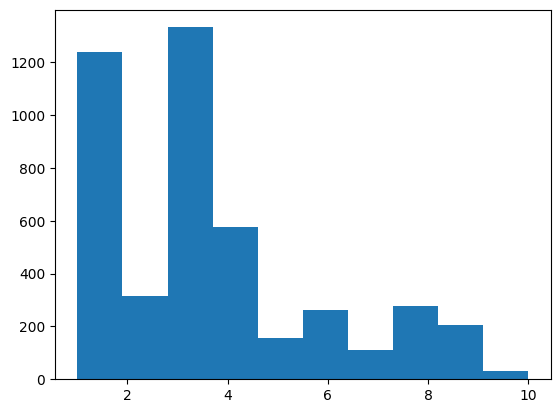

In [9]:
plt.hist(df['Hem_mal'])
import numpy as np
print(len(df_col_utils[df_col_utils['Charlson_index']>7]))
print(len(df_col_utils))
np.median(df_col_utils['Charlson_index'])

In [10]:
df = pd.read_excel(r"C:\Users\romai\Desktop\travail\EFRAIM3 JD VANCE.xlsx")

(df_cat_clean == 0).all(axis=1).sum(), df["Etiology_Undetermined cause_Definitive diagnosis"].fillna(0).sum()

(np.int64(0), np.float64(442.0))

In [ ]:
pd.concat([df_cat_clean,df_features_clean],axis=1)


,Bacterial infection,Viral infection,Invasive pulmonary aspergillosis,Pneumocystis jirovecii infection,Mucorales,Other fungal,Other infection,Cardiogenic pulmonary oedema,Drug toxicity related,Disease-related infiltrates,...,HSCT_BMT_Autograft,HSCT_BMT_Allograft,Nodules_any,Opacity,SOFA_scaled,Sa02,Resp_severity,Temp_gravité,Leukostase,Neutropenie
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.291667,0.964451,1.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.250000,0.969083,1.0,0.0,0.0,0.0
4,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.666667,0.967334,2.0,0.6,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.208333,0.966409,1.0,0.6,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.083333,0.963413,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9846,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.333333,0.950395,3.0,0.6,0.0,0.0
9848,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.291667,0.000000,2.0,0.0,0.0,0.0
9851,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.416667,0.941505,2.0,0.0,0.0,0.0
9852,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.041667,0.954877,1.0,0.0,0.0,0.0


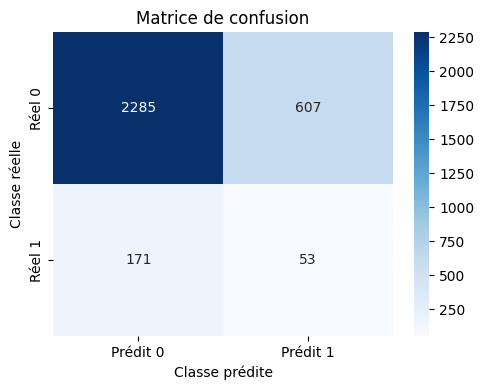

{'accuracy': 0.7503209242618742, 'precision': 0.0803030303030303, 'recall': 0.23660714285714285, 'confusion_matrix': array([[2285,  607],
       [ 171,   53]]), 'roc_auc': 0.5824843163406441}


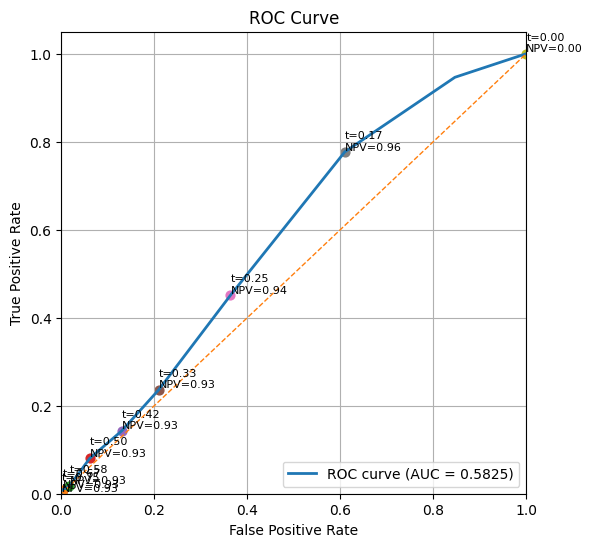

ROC AUC = 0.5825


In [5]:
sys.modules.pop('utils.stats_dataset', None)

from utils.stats_dataset import Score_alice
from utils.algo_prediction import calculate_score
from utils.visualisation import show_roc_curve

ipa_truth = df_cat_clean["Invasive pulmonary aspergillosis"]
df_all  = pd.concat([df_cat_clean,df_features_clean],axis=1)
results = calculate_score(df_all, ipa_truth, Score_alice,
                          metrics=["accuracy", "precision", "recall", "confusion_matrix","roc_auc"])
print(results["metrics"])
# y_pred = Score_alice.predict(df_all)
# y_test = ipa_truth
# print(y_pred.sum())
y_pred = results["y_pred"]
y_test = results["y_true"]

auc_value = show_roc_curve(y_test, y_pred, pos_label=1)

In [30]:
print(len(df),len(df_cat_clean),len(df_features_clean))

3244 3244 3244


In [7]:
df_features_clean.columns

Index(['Sex', 'Time H-ICU', 'TIME SYMPTOMES-ICU', 'Time  DG-ICU', 'Sys_dis',
       'Solid_tumor', 'Organ_transpl', 'Drug_induced', 'Chemotherapy',
       'Ibr_Flu_Met', 'Immuno_drugs', 'Tar_ther', 'Immunotherapy',
       'Carttcells', 'Steroids_YN', 'Charlson_index',
       'Prophylaxis_pneumocystis', 'Prophylaxis_antifungal',
       'Prophylaxis_bacterial', 'Prophylaxis_viral', 'Vaccins#Flu',
       'Vaccins#COVID', 'Vaccins#Other', 'Glasgow', 'Hemoptysis',
       'PaO2/FiO2 VALUE VALUE', 'Pleural_eff', 'Quad_no', 'Excavation',
       'Septal_line', 'Halo_sign', 'Lymph_bulky', 'Age_scaled', 'Hem_mal_AML',
       'Hem_mal_ALL', 'Hem_mal_Non_hodgkin_lymphoma', 'Hem_mal_myeloma',
       'Hem_mal_hodgkin_lymphoma', 'Hem_mal_CLL', 'Hem_mal_CML', 'Hem_mal_MDS',
       'Hem_mal_other', 'Disease_status_inaugural', 'Disease_status_remission',
       'Disease_status_evolutive', 'rejet_allograft', 'HSCT_BMT_Autograft',
       'HSCT_BMT_Allograft', 'Nodules_any', 'GGO', 'SOFA_scaled', 'Sa02',
  

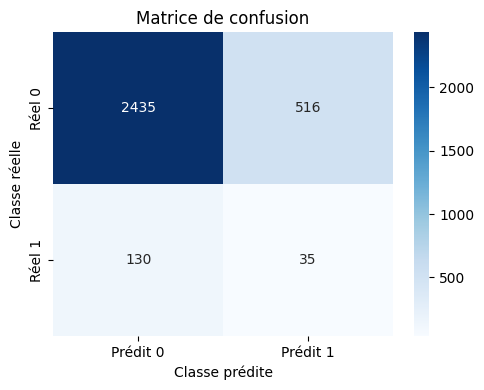

{'accuracy': 0.7926829268292683, 'precision': 0.06352087114337568, 'recall': 0.21212121212121213, 'confusion_matrix': array([[2435,  516],
       [ 130,   35]]), 'roc_auc': 0.5471447788628406}


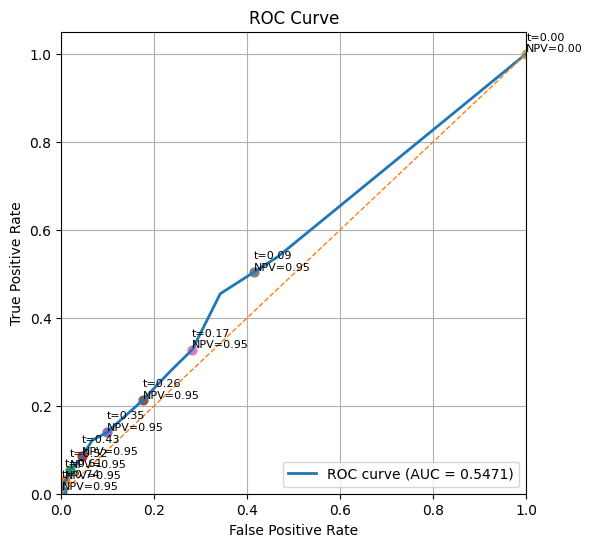

ROC AUC = 0.5471


In [11]:
sys.modules.pop('utils.stats_dataset', None)

from utils.stats_dataset import Score_pneumo
from utils.algo_prediction import calculate_score
from utils.visualisation import show_roc_curve
df = df.loc[df_features_clean.index]
pneumo_truth = df_cat_clean["Pneumocystis jirovecii infection"]
df_all  = pd.concat([df_cat_clean,df_features_clean,df[["Age","Vasopressors","Alveolar_xray"]]],axis=1)
results = calculate_score(df_all, pneumo_truth, Score_pneumo,
                          metrics=["accuracy", "precision", "recall", "confusion_matrix","roc_auc"])
print(results["metrics"])
y_pred = results["y_pred"]
y_test = results["y_true"]

auc_value = show_roc_curve(y_test, y_pred, pos_label=1)

In [54]:
y_test.value_counts()

Pneumocystis jirovecii infection
0    2951
1     165
Name: count, dtype: int64

(array([12.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([1.0000e+00, 2.3710e+02, 4.7320e+02, 7.0930e+02, 9.4540e+02,
        1.1815e+03, 1.4176e+03, 1.6537e+03, 1.8898e+03, 2.1259e+03,
        2.3620e+03]),
 <BarContainer object of 10 artists>)

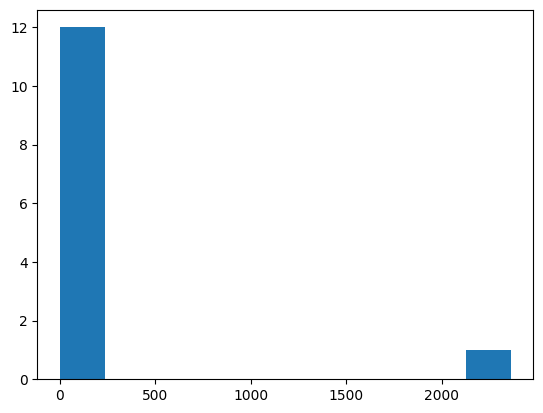

In [ ]:
plt.hist(y_pred.value_counts())

In [ ]:
sys.modules.pop('utils.stats_dataset', None)

from utils.stats_dataset import Score_alice
i_loc = 0
Score_alice(df_features_clean.iloc[i_loc])[2],df_cat_clean.iloc[i_loc]["Invasive pulmonary aspergillosis"]

np.True_

In [24]:
from utils.feature_transformer import ETIOLOGY_COLUMNS, _encode_dg1_etiology
from pathlib import Path
sys.modules.pop('utils.stats_dataset', None)
df_new_diag = _encode_dg1_etiology(df[["DG1","BiTE"]])
from utils.stats_dataset import compare_dg1_dataframes, plot_confusion_heatmap

summary, mismatches, confusion = compare_dg1_dataframes(df, df_new_diag, output_path=Path("dg1_diff.csv"))


6916 lignes divergent.


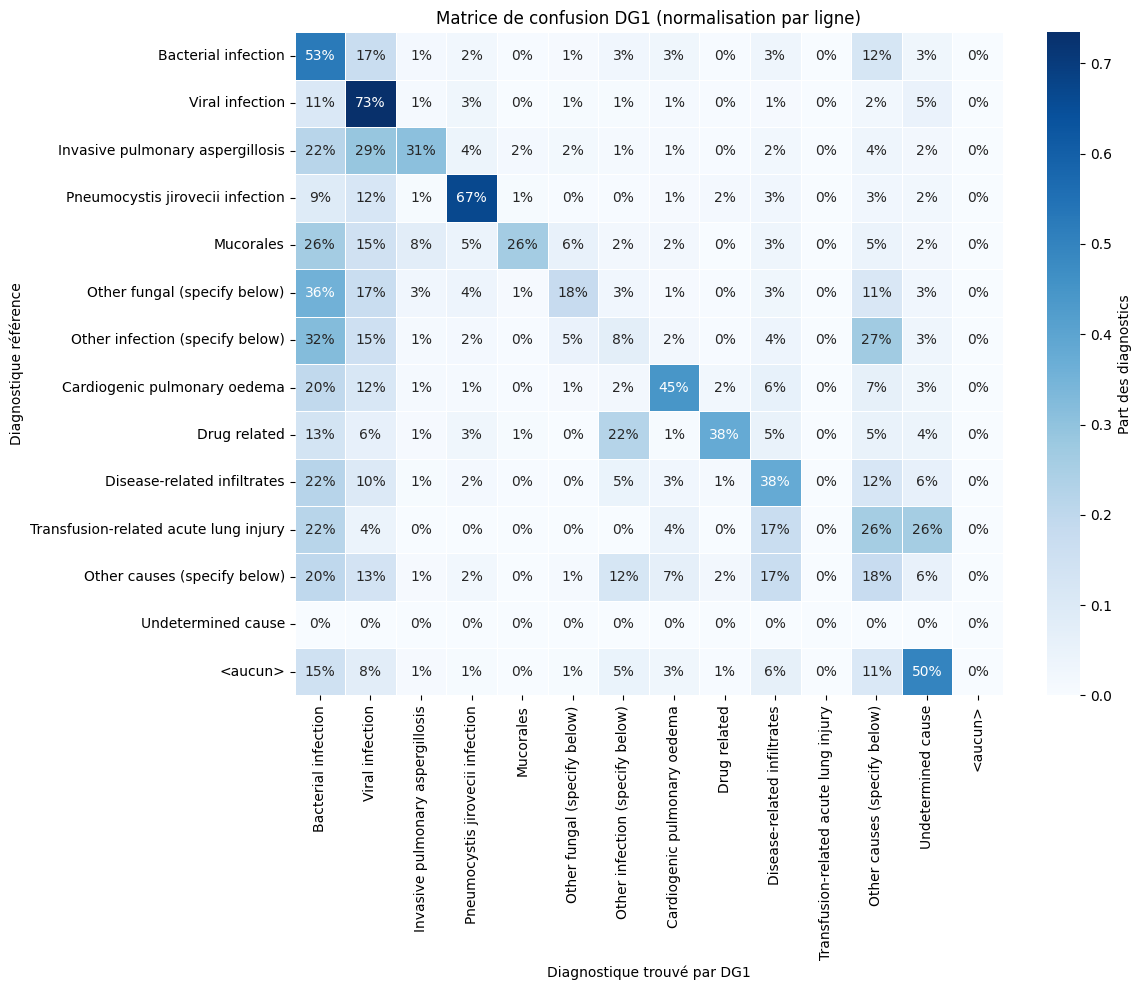

In [25]:
from utils.data_quality import extraire_contenu_central
confusion.columns = [extraire_contenu_central(col) for col in confusion.columns]
confusion.index = [extraire_contenu_central(idx) for idx in confusion.index]
plot_confusion_heatmap(confusion, normalize="row")  # column / all / None selon le besoin

print(f"{len(mismatches)} lignes divergent.")

<Axes: >

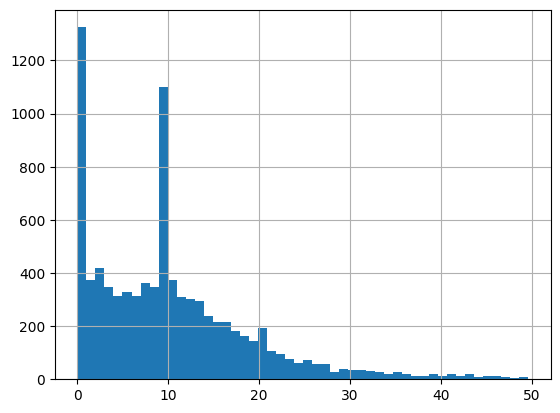

In [ ]:
df_col_utils[df_col_utils["Leukocytes"] < 50]["Leukocytes"].hist(bins=50)

In [28]:
((df_col_utils["Leukocytes"] > 50 ) & (df_col_utils["Hem_mal"] != 0 )).sum()

np.int64(437)

In [6]:

df_etude = df_features_clean[['Vasopressors','Septic_shock']]

df_etude.value_counts()

Vasopressors  Septic_shock
0.0           0.0             3961
1.0           1.0             3192
              0.0             2086
0.0           1.0              176
Name: count, dtype: int64

Nombre de lignes contenant plus d’un '1' : 2383

Distribution des valeurs positives (1) par colonne (% des données totales) :
Bacterial infection                      38.22
Other causes (specify below)             27.29
Viral infection                          25.33
Cardiogenic pulmonary oedema             11.60
Disease-related infiltrates              10.67
Pneumocystis jirovecii infection          4.59
Invasive pulmonary aspergillosis          4.52
Other fungal (specify below)              3.64
Drug related                              3.64
Other infection (specify below)           3.25
Mucorales                                 1.21
Transfusion-related acute lung injury     0.32
dtype: float64


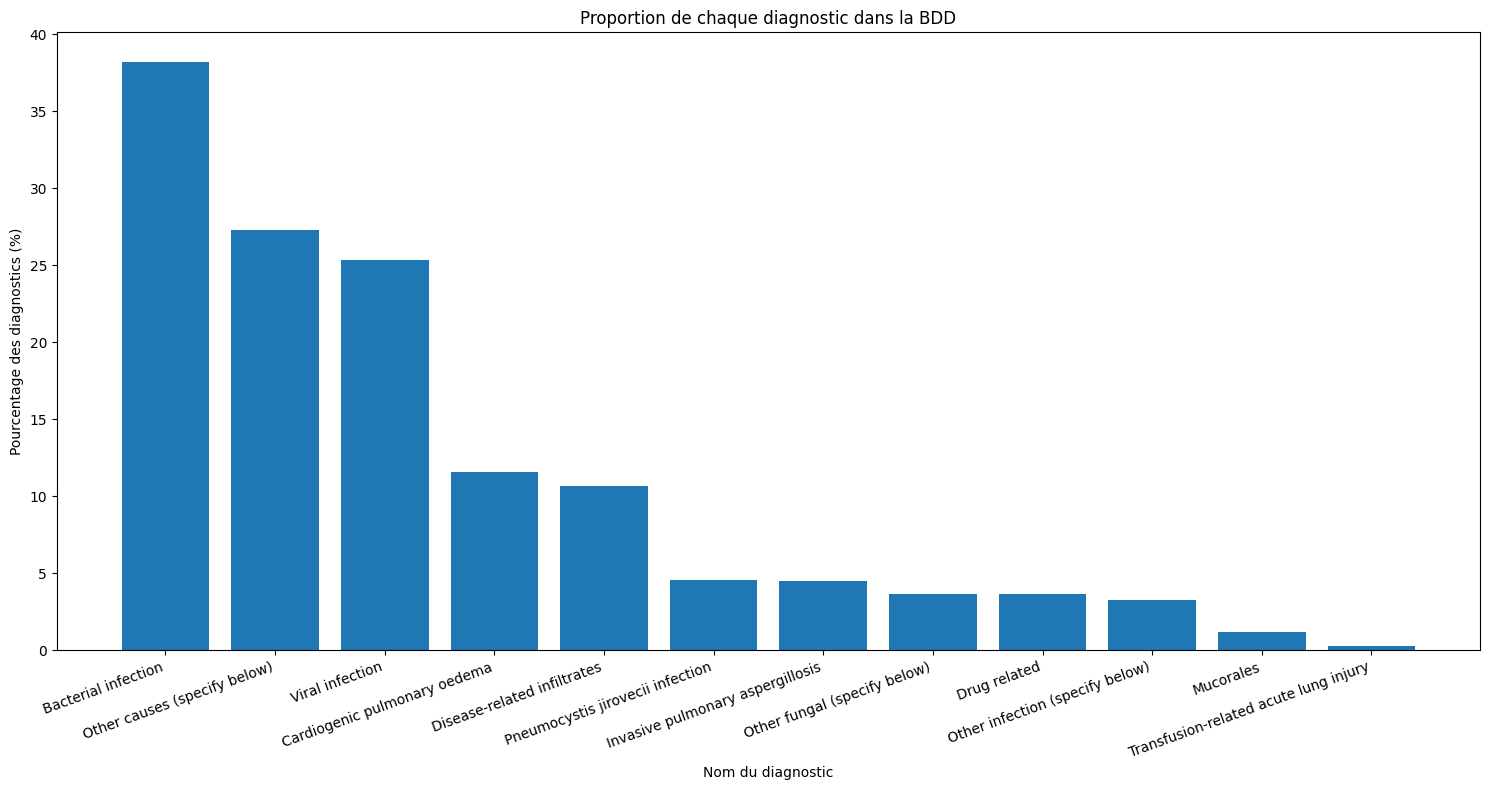

In [4]:
from utils.stats_dataset import analyser_variables_binaires,analyser_associations_binaires
distribution, nb_lignes = analyser_variables_binaires(df_cat_clean)

Nombre de lignes contenant plus d’un '1' : 2383

Associations les plus fréquentes (% des lignes totales) :
                                         Association  Fréquence  Pourcentage
0             (Bacterial infection, Viral infection)        645         8.90
1  (Bacterial infection, Other causes (specify be...        634         8.74
2    (Other causes (specify below), Viral infection)        366         5.05
3  (Bacterial infection, Disease-related infiltra...        251         3.46
4  (Bacterial infection, Cardiogenic pulmonary oe...        239         3.30


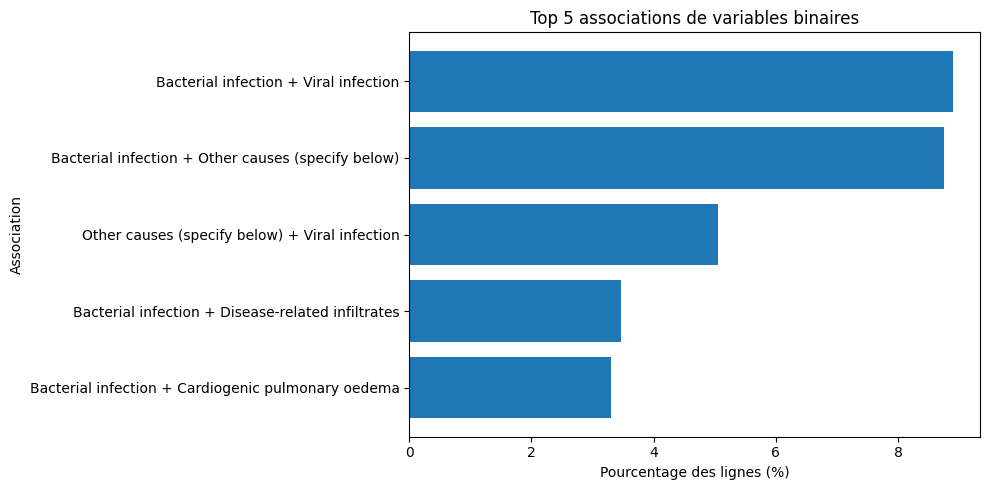

In [5]:
assoc_df, lignes_multi = analyser_associations_binaires(df_cat_clean, top_n=5)

Nombre de lignes totalement vides : 1627


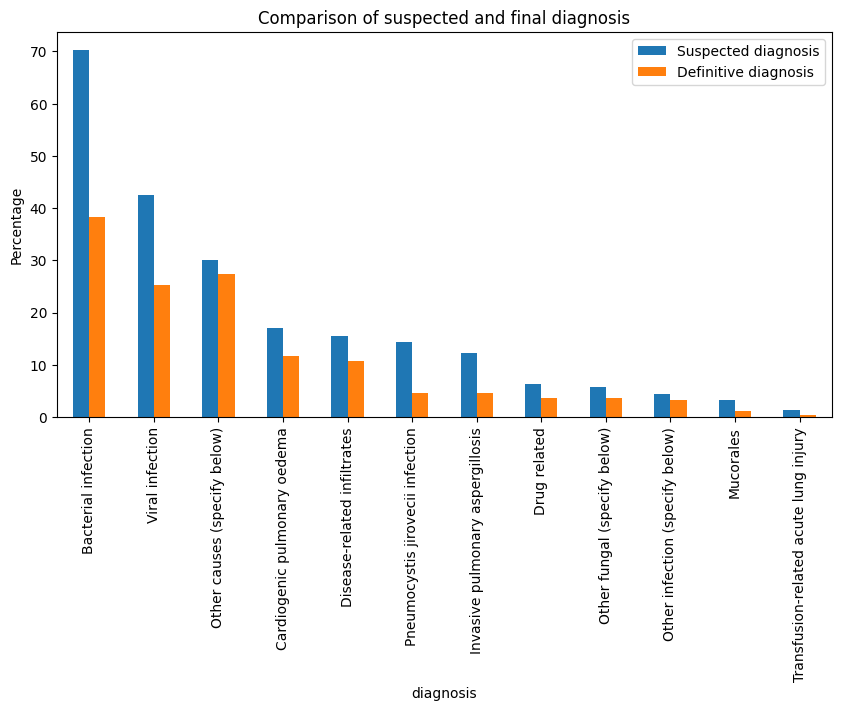

In [6]:

features_suspected = [col.replace("Definitive diagnosis", "Suspected at ICU adm") for col in features_etiology]
df_suspected = df[features_suspected]
df_suspected = nettoyer_colonnes(df_suspected)
df_suspected = nettoyer_lignes_vides(df_suspected)
distribution_suspected, nb_lignes = analyser_variables_binaires(df_suspected,print_results=False,visualisation=False)
distribution_diagnostique, nb_lignes = analyser_variables_binaires(df_cat_clean,print_results=False,visualisation=False)
import matplotlib.pyplot as plt
df_stats_suspected_vs_definitive = pd.concat([distribution_suspected, distribution_diagnostique], axis=1)
df_stats_suspected_vs_definitive.columns = ['Suspected diagnosis','Definitive diagnosis']

df_stats_suspected_vs_definitive.plot(kind='bar', figsize=(10, 5))
plt.xlabel('diagnosis')
plt.ylabel('Percentage')
plt.title('Comparison of suspected and final diagnosis')
plt.legend()
plt.show()


In [5]:
df_features_clean = df_features_clean.loc[df_cat_clean.index]
df_clean = pd.concat([df_features_clean,df_cat_clean], axis=1)

# Aucun prophilaxy et diagnostique

In [ ]:

cond_proph = df_clean["Prophylaxis_antifungal"] == 1

cond_fungal = (
    (df_clean["Mucorales"] == 1) |
    (df_clean["Other fungal (specify below)"] == 1) |
    (df_clean["Invasive pulmonary aspergillosis"] == 1)
)

ean = df_clean[cond_proph & cond_fungal]
# Nombre total
n_total_proph = cond_proph.sum()
n_total_fungal = cond_fungal.sum()
n_both = (cond_proph & cond_fungal).sum()

# Pourcentages
pct_proph = n_both / n_total_proph * 100 if n_total_proph > 0 else 0
pct_fungal = n_both / n_total_fungal * 100 if n_total_fungal > 0 else 0
print("=== Résultats ===")
print(f"Nombre total de patients : {len(df_clean)}")
print(f"Nombre total prophylaxie antifongique : {n_total_proph}")
print(f"Nombre total infection fongique      : {n_total_fungal}")
print(f"Nombre avec les deux conditions       : {n_both}")

print("\n=== Proportions ===")
print(f"→ Parmi les patients prophylaxés : {pct_proph:.2f}% ont une infection fongique.")
print(f"→ Parmi les patients infectés    : {pct_fungal:.2f}% avaient une prophylaxie.")


=== Résultats ===
Nombre total prophylaxie antifongique : 989
Nombre total infection fongique      : 626
Nombre avec les deux conditions       : 148

=== Proportions ===
→ Parmi les patients prophylaxés : 14.96% ont une infection fongique.
→ Parmi les patients infectés    : 23.64% avaient une prophylaxie.


In [ ]:

cond_proph = df_clean["Prophylaxis_pneumocystis"] == 1

cond_fungal = (
    (df_clean['Pneumocystis jirovecii infection'] == 1 )
)

ean = df_clean[cond_proph & cond_fungal]

print("exemple des lignes avec prophylaxie et diagnostiques : ",ean.index)
# Nombre total
n_total_proph = cond_proph.sum()
n_total_fungal = cond_fungal.sum()
n_both = (cond_proph & cond_fungal).sum()

# Pourcentages
pct_proph = n_both / n_total_proph * 100 if n_total_proph > 0 else 0
pct_fungal = n_both / n_total_fungal * 100 if n_total_fungal > 0 else 0
print("=== Résultats ===")
print(f"Nombre total de patients : {len(df_clean)}")
print(f"Nombre total prophylaxie antipneucystis : {n_total_proph}")
print(f"Nombre total pneumocystose    : {n_total_fungal}")
print(f"Nombre avec les deux conditions       : {n_both}")

print("\n=== Proportions ===")
print(f"→ Parmi les patients prophylaxés : {pct_proph:.2f}% ont une pneumocystose.")
print(f"→ Parmi les patients infectés    : {pct_fungal:.2f}% avaient une prophylaxie.")


57 1436 333
Index([ 650,  762,  915,  937, 1108, 1119, 1411, 1880, 2127, 2157, 2317, 2328,
       2372, 2522, 2533, 2686, 2735, 2900, 2980, 2988, 2995, 2996, 3015, 3037,
       3072, 3092, 3141, 3149, 3291, 3387, 3622, 3788, 4075, 4171, 4555, 4668,
       4716, 4753, 4761, 4885, 4892, 5011, 5037, 5038, 5057, 5082, 5359, 5398,
       5494, 5747, 5796, 6270, 6836, 8481, 8598, 8979, 9392],
      dtype='int64')
=== Résultats ===
Nombre total de patients : 7251
Nombre total prophylaxie antipneucystis : 1436
Nombre total pneumocystose    : 333
Nombre avec les deux conditions       : 57

=== Proportions ===
→ Parmi les patients prophylaxés : 3.97% ont une pneumocystose.
→ Parmi les patients infectés    : 17.12% avaient une prophylaxie.


# Colinearite

🔹 Age → NaN remplacés par la médiane (64.0)
🔹 Time H-ICU → NaN remplacés par la médiane (2.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (2.0)
🔹 SOFA_score → NaN remplacés par la médiane (7.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 Temp → NaN remplacés par la médiane (37.3)
🔹 Neutrophils → NaN remplacés par la médiane (7.17)
🔹 Leukocytes → NaN remplacés par la médiane (9.51)
🔹 Quad_no → NaN remplacés par la médiane (3.0)

✅ Nettoyage terminé. NaN restants : 0
Nombre de lignes totalement vides : 2164
Nombre de lignes totalement vides : 0


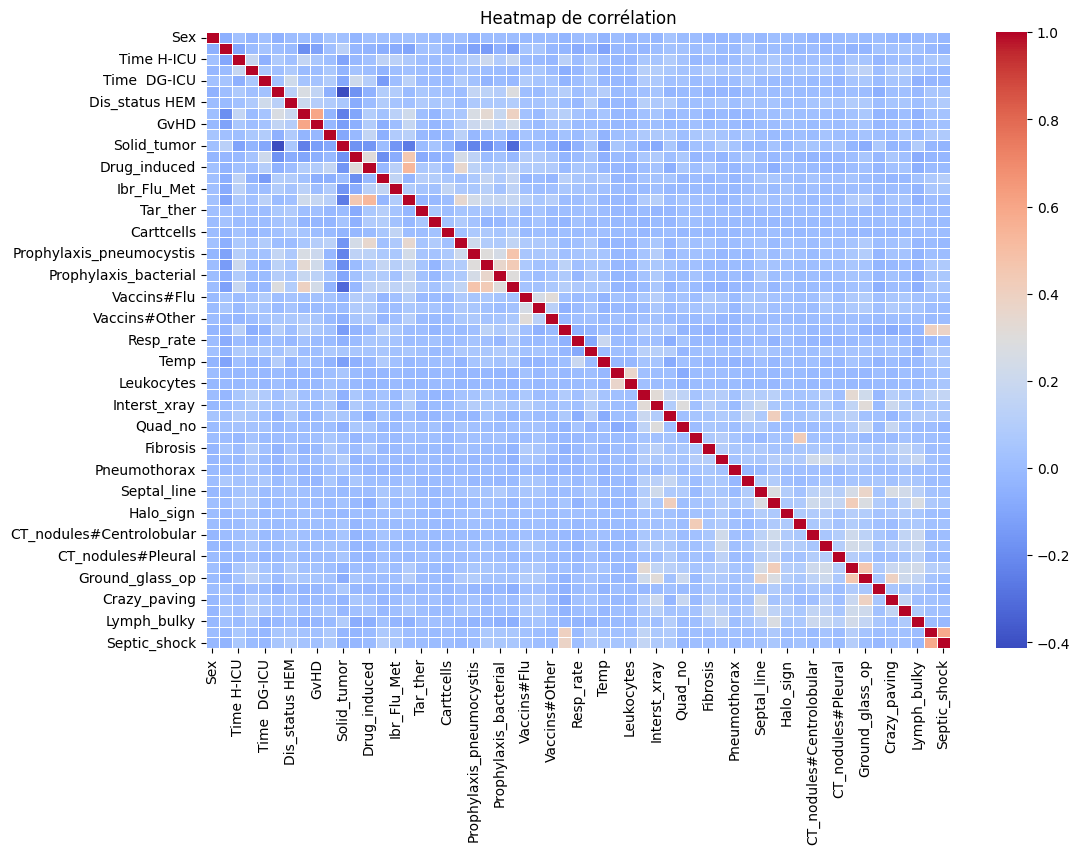


📌 Paires de features fortement corrélées (>|0.7|) :
Aucune corrélation forte détectée.

📌 VIF des features :
                           feature        VIF
30                            Temp  70.284494
1                              Age  21.626218
29                            SpO2  20.268927
28                       Resp_rate  15.577671
27                      SOFA_score   7.541671
36                         Quad_no   6.139103
55                    Vasopressors   3.731935
6                   Dis_status HEM   2.946459
10                     Solid_tumor   2.619067
15                    Immuno_drugs   2.535369
56                    Septic_shock   2.534558
33                   Alveolar_xray   2.491790
49                   Alveolar_cons   2.411976
34                    Interst_xray   2.392189
12                    Drug_induced   2.357967
50                 Ground_glass_op   2.347903
7                         HSCT_BMT   2.311336
43                  CT_Pleural_eff   2.294891
23              

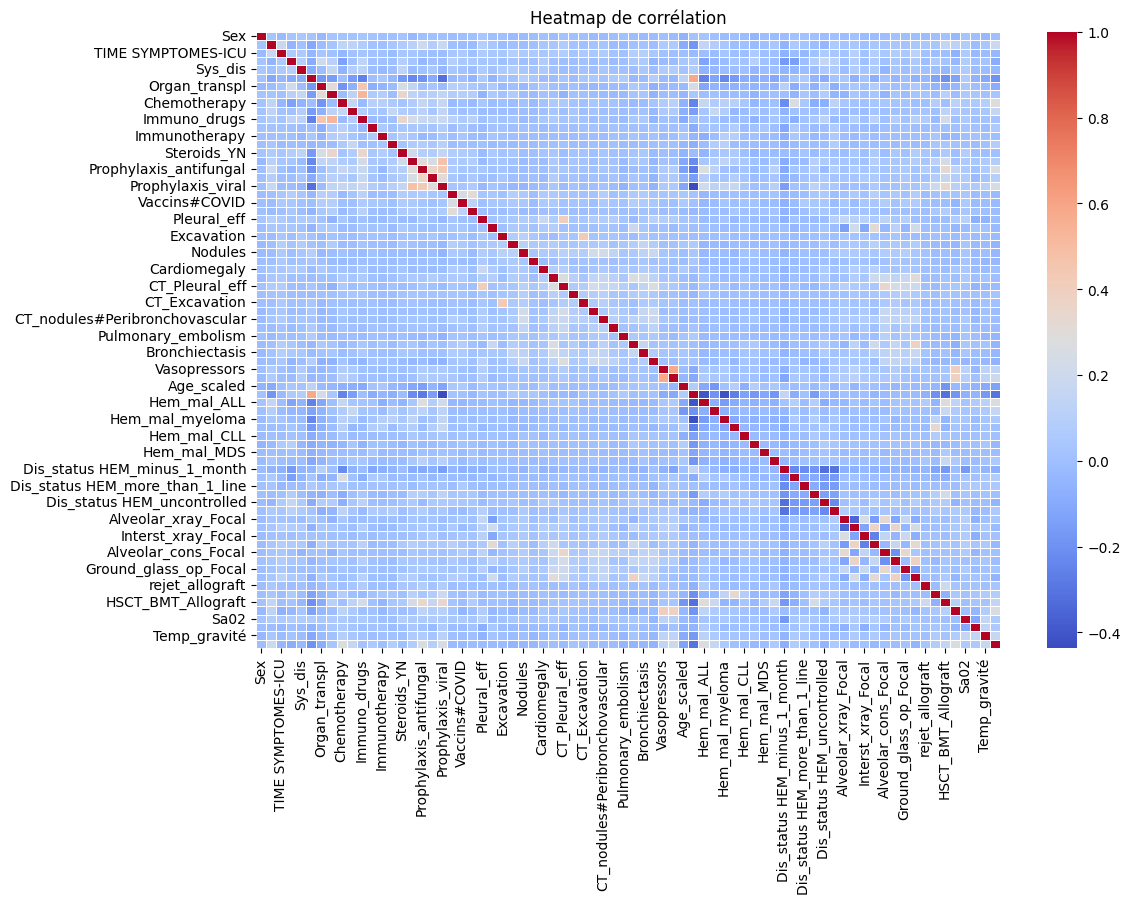


📌 Paires de features fortement corrélées (>|0.7|) :
Aucune corrélation forte détectée.

📌 VIF des features :
                         feature        VIF
70                          Sa02  20.105127
43                   Hem_mal_AML  16.713234
42                    Age_scaled  11.461775
69                   SOFA_scaled   7.387693
52  Dis_status HEM_minus_1_month   6.955050
..                           ...        ...
36            Pulmonary_embolism   1.077671
13                    Carttcells   1.069325
31                     Halo_sign   1.062437
66               rejet_allograft   1.056675
27                  Pneumothorax   1.042088

[74 rows x 2 columns]


In [7]:
from utils.stats_dataset import analyze_collinearity
from utils.data_quality import analyser_nan,nettoyer_lignes_vides,nettoyer_colonnes
from utils.feature_transformer import transform_features, _convert_all_columns_to_numeric
from utils.data_quality import nettoyer_nan_par_colonne
Liste_features = Liste_features_simple + features_radiology_dysfunction
df_col_utils = df[Liste_features]
df_category = df[features_etiology]
L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score","Neutrophils","Temp","Sp02","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features
}
df_col_utils = _convert_all_columns_to_numeric(df_col_utils)
# print(df_col_utils.columns)

df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)
df_features_clean = _convert_all_columns_to_numeric(df_features_clean)

df_category = nettoyer_colonnes(df_category)
df_cat_clean = nettoyer_lignes_vides(df_category)
df_col_utils = nettoyer_lignes_vides(df_col_utils)
vif_results = analyze_collinearity(df_col_utils)
vif_results_clean = analyze_collinearity(df_features_clean)



In [26]:
for index, row in vif_results_clean.iterrows():
    
    if row['VIF'] > 2:
        print(f"Feature '{row['feature']}' has a high VIF of {row['VIF']:.2f}, indicating potential multicollinearity.")
        print(df_features_clean.corr()[row['feature']].abs().sort_values(ascending=False)[:3])


Feature 'Sa02' has a high VIF of 20.11, indicating potential multicollinearity.
Sa02                            1.000000
Dis_status HEM_minus_1_month    0.167835
Temp_gravité                    0.162818
Name: Sa02, dtype: float64
Feature 'Hem_mal_AML' has a high VIF of 16.71, indicating potential multicollinearity.
Hem_mal_AML          1.000000
Solid_tumor          0.583108
Prophylaxis_viral    0.436350
Name: Hem_mal_AML, dtype: float64
Feature 'Age_scaled' has a high VIF of 11.46, indicating potential multicollinearity.
Age_scaled                      1.000000
HSCT_BMT_Allograft              0.184506
Hem_mal_Non_hodgkin_lymphoma    0.178149
Name: Age_scaled, dtype: float64
Feature 'SOFA_scaled' has a high VIF of 7.39, indicating potential multicollinearity.
SOFA_scaled     1.000000
Vasopressors    0.400826
Septic_shock    0.380640
Name: SOFA_scaled, dtype: float64
Feature 'Dis_status HEM_minus_1_month' has a high VIF of 6.96, indicating potential multicollinearity.
Dis_status HEM_minu

In [18]:
import sys 
sys.modules.pop('utils.visualisation',None)

<module 'utils.visualisation' from 'c:\\Users\\romai\\Desktop\\codes\\respiratory_diagnostics\\utils\\visualisation.py'>

# Scikit multilearn

In [20]:
len(df_cat_clean)

6360

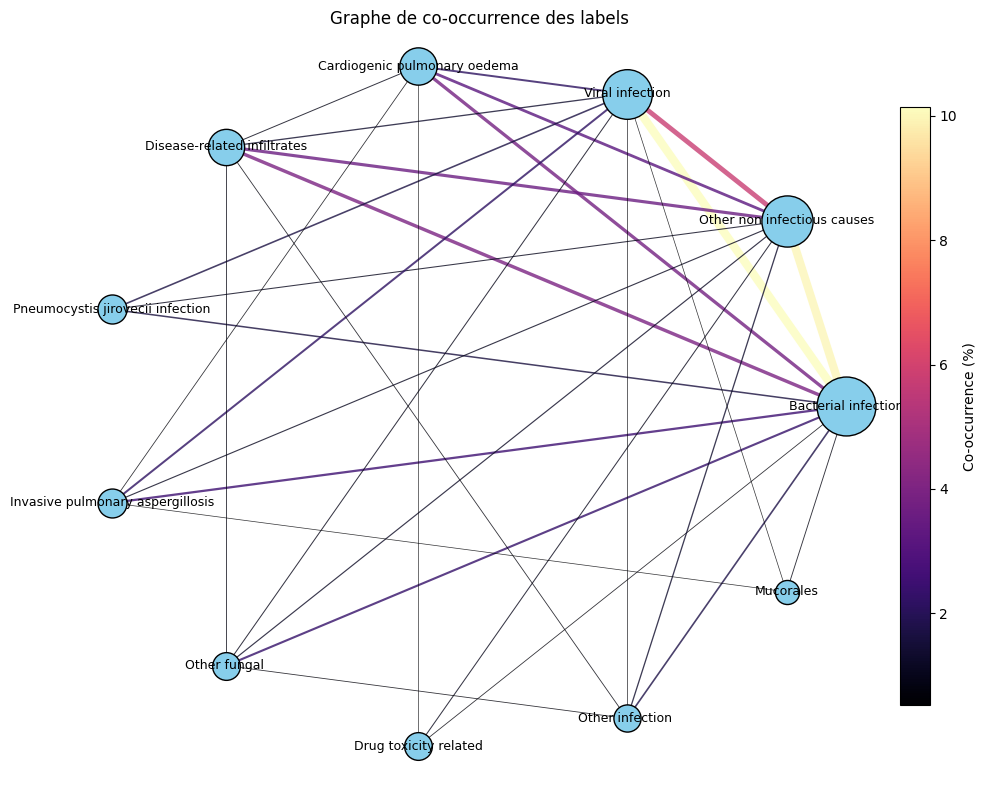

In [19]:
from utils.visualisation import plot_multilabel_cooccurrence

# df_cat_clean = votre Y one-hot
from utils.visualisation import plot_multilabel_network_matplotlib
fig, ax = plot_multilabel_network_matplotlib(
    df_cat_clean,
    min_support=0.01,   # garde labels présents dans >=1% des lignes
    top_k=20,           # prend les 20 plus fréquents
    normalize="percent",
    edge_threshold=0.5, # n’affiche que co-occurrences >= 0.5%
    annot_edges=False,
    annot_nodes=True,
)
plt.show()

In [16]:
import networkx

AttributeError: 'wrapper_descriptor' object has no attribute '__annotate__'

In [ ]:
from get_rpps import  verifier_rpps


rpps_cible = "10004133012"

resultats = verifier_rpps(rpps_cible)

if resultats.empty:
    print(f"Le numéro RPPS {rpps_cible} est absent de la base.")
else:
    print(f"RPPS {rpps_cible} trouvé :")
    print(resultats.to_string(index=False))